<a href="https://colab.research.google.com/github/Karimkhab/introduction-to-machine-learning/blob/main/my_training_in_life_coding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

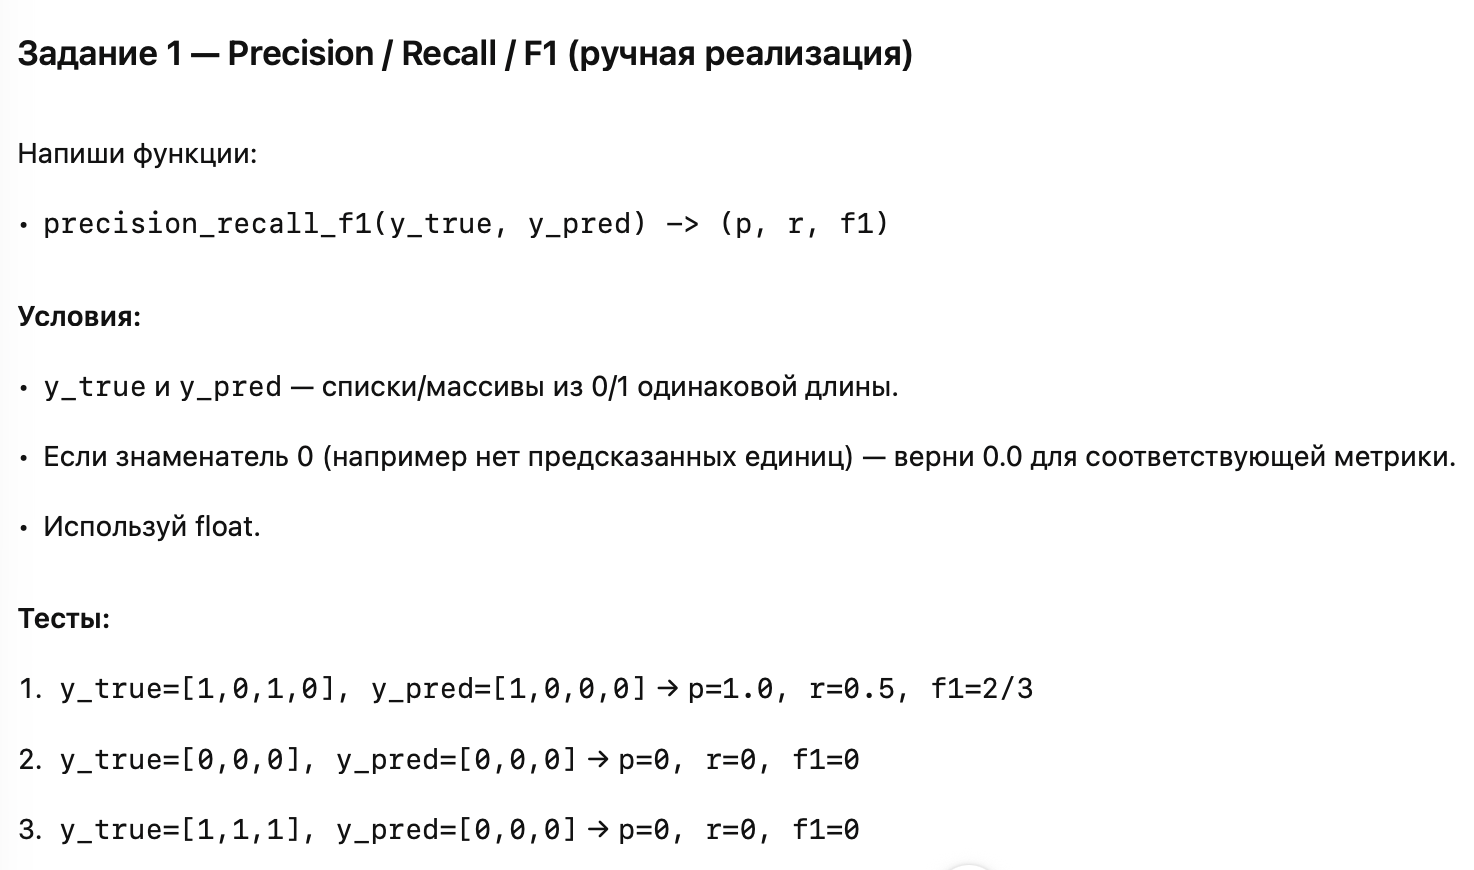

In [9]:
import numpy as np

In [39]:
def precision_recall_f1(y_true : np.array, y_pred : np.array) -> tuple[float, float, float]:
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    precision = 0 if (TP + FP) == 0 else TP / (TP + FP)
    recall =0 if (TP + FN) == 0 else TP / (TP + FN)

    f1 = 0 if (precision + recall) == 0 else  2 * (precision * recall) / (precision + recall)
    return float(precision), float(recall), float(f1)
assert(precision_recall_f1(np.array([1,0,1,0]), np.array([1,0,0,0])) == (1.0, 0.5, 2/3))
assert(precision_recall_f1(np.array([0,0,0]), np.array([0,0,0])) == (0.0, 0.0, 0.0))
assert(precision_recall_f1(np.array([1,1,1]), np.array([0,0,0])) == (0.0, 0.0, 0.0))

In [35]:
precision_recall_f1(np.array([1,0,1,0]), np.array([1,0,0,0])), (1.0, 0.5, 2/3)

1 2 0 1


((1.0, 0.5, 0.6666666666666666), (1.0, 0.5, 0.6666666666666666))

In [36]:
precision_recall_f1(np.array([0,0,0]), np.array([0,0,0]))

0 3 0 0


(0.0, 0.0, 0.0)

In [37]:
assert(precision_recall_f1(np.array([1,0,1,0]), np.array([1,0,0,0])) == (1.0, 0.5, 2/3))
assert(precision_recall_f1(np.array([0,0,0]), np.array([0,0,0])) == (0.0, 0.0, 0.0))
assert(precision_recall_f1(np.array([1,1,1]), np.array([0,0,0])) == (0.0, 0.0, 0.0))

1 2 0 1
0 3 0 0
0 0 0 3


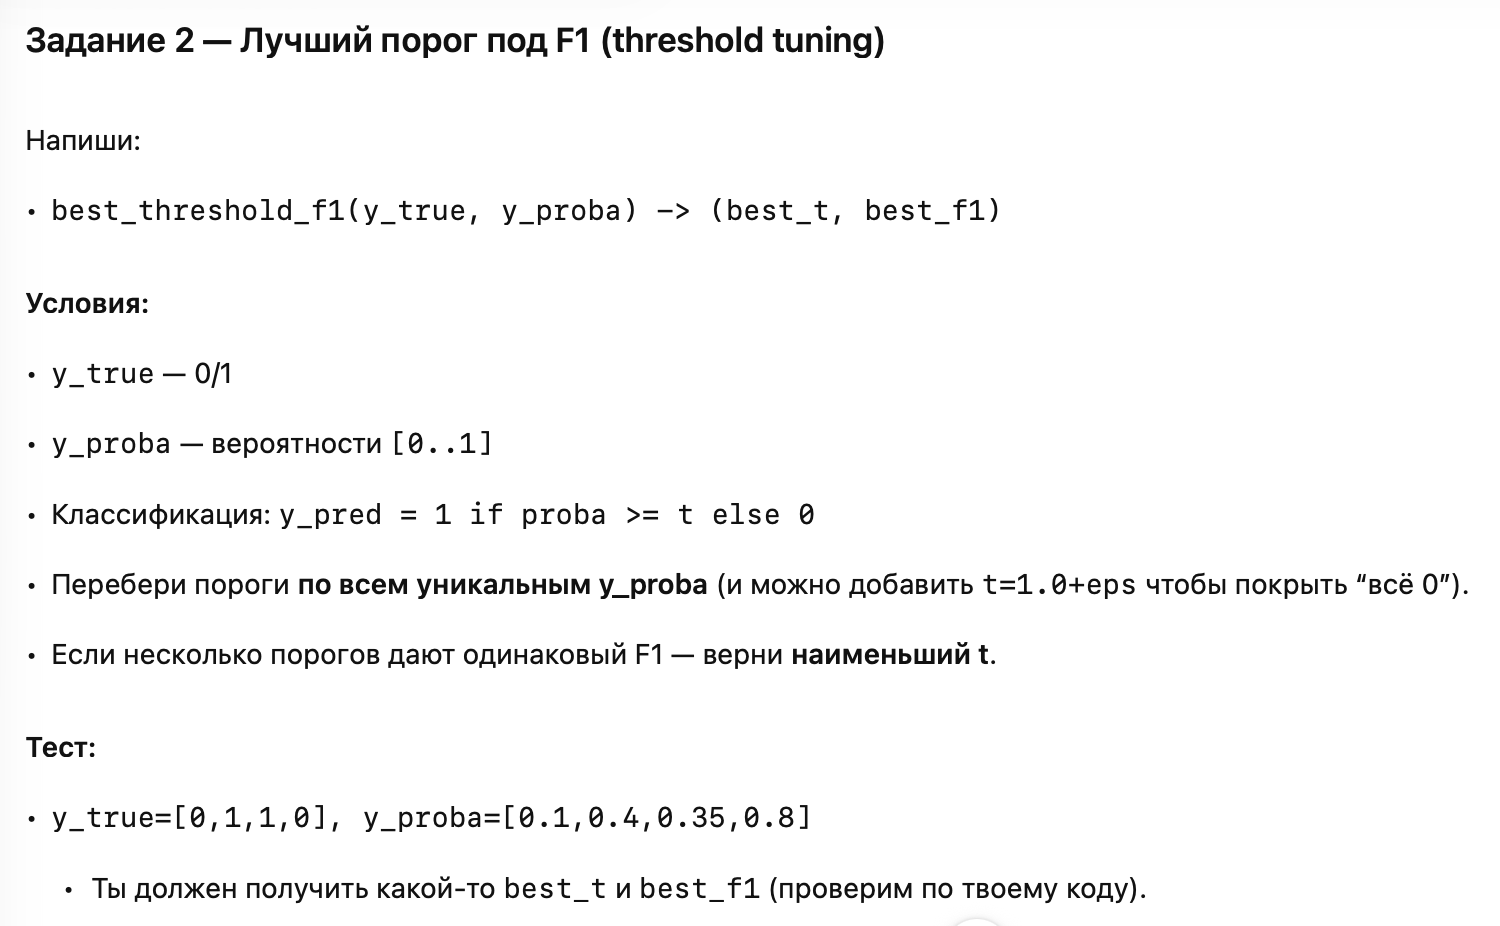

In [43]:
def best_threshold(y_true : np.array, y_proba : np.array) -> tuple[float, float]:
    thresholds = np.linspace(0, 1, 1000)
    best_t, best_f1 = 0.5, 0.0
    for threshold in thresholds:
        y_pred = (y_proba > threshold).astype(int)
        _, _, f1 = precision_recall_f1(y_true, y_pred)
        if f1 > best_f1:
            best_t, best_f1 = threshold, f1
    return float(best_t), float(best_f1)
best_threshold(y_true = np.array([0,1,1,0]), y_proba = np.array([0.1,0.4,0.35,0.8]))


(0.10010010010010009, 0.8)

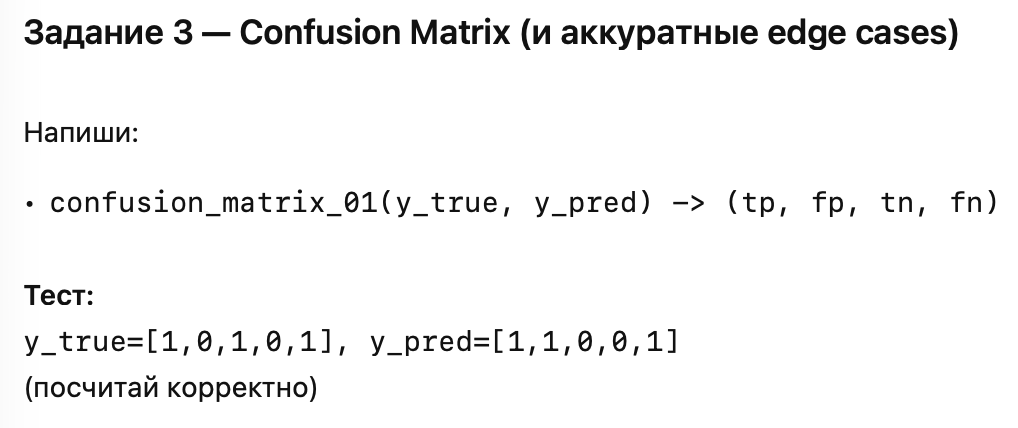

In [11]:
from typing import List, Any, Tuple, Optional

In [12]:
def confusion_matrix_01(y_true : np.array | List, y_pred : np.array | List) -> tuple[int,int,int,int]:
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return int(TP), int(FP), int(TN),  int(FN)
confusion_matrix_01(np.array([1,0,1,0,1]), np.array([1,1,0,0,1]))

(2, 1, 1, 1)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_scaled = StandardScaler().fit_transform(X) # <- здесь есть leakage поскольку мы до сплита преобразуем наше множество признаков то есть дальше когда мы будем делать сплит на трейн и тест наш scaler будет знать среднее и отклонение не по выборке а по популяции тип правильно бы сделать по другому ниже скину исправленный код
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
pred = model.predict_proba(X_val)[:, 1]

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter = 200))
])
pipe.fit(X_train, y_train)
pred = pipe.predict_proba(X_val)[:, 1]

In [5]:
import pandas as pd

In [13]:
def time_split(df : pd.DataFrame, date_col : str = "date", frac_train: float = 0.8) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = df.copy()
    df[date_col] = pd.to_datatime(df[date_col])

    df.sort_values(by = date_col, inplace = True)

    cut = int(len(df) * frac_train)
    train_df = df.iloc[: cut]
    val_df = df.iloc[cut : ]

    return train_df, val_df

In [7]:
def top_k_frequent(nums : list, k : int) -> list:
    from collections import Counter
    import heapq

    counter = Counter(nums)
    return heapq.nlargest(k, counter.keys(), key = counter.get)